# Taller Práctico - Machine Learning con Loan Approval Dataset

## Objetivo
Aplicar un flujo base de Machine Learning para resolver un problema de **clasificación**, usando el archivo de entrenamiento `train_u6lujuX_CVtuZ9i.csv` y dejando el archivo `test_Y3wMUE5_7gLdaTN.csv` para predicción final.



In [49]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

SEED = 42
TRAIN_PATH = Path("train_u6lujuX_CVtuZ9i.csv")
TEST_PATH = Path("test_Y3wMUE5_7gLdaTN.csv")
TARGET_COLUMN = "Loan_Status"
ID_COLUMN = "Loan_ID"


## Parte 1 - Comprensión del problema

### Variable objetivo
`Loan_Status`

### ¿Clasificación o regresión?
Es un problema de **clasificación**.

### ¿Por qué?
Porque queremos predecir una categoría discreta: si el préstamo es aprobado o no (`Y` o `N`). No estamos estimando un valor numérico continuo.

### Contexto breve
El dataset representa solicitudes de préstamo con variables demográficas, laborales, geográficas y financieras. El objetivo es predecir si una solicitud será aprobada.


In [50]:
datos_entrenamiento = pd.read_csv(TRAIN_PATH)
datos_prueba = pd.read_csv(TEST_PATH)

print("Train shape:", datos_entrenamiento.shape)
print("Test shape:", datos_prueba.shape)
print()
print("Columnas train:")
print(datos_entrenamiento.columns.tolist())
print()
print("Columnas test:")
print(datos_prueba.columns.tolist())
print()
print("Primeras filas train:")
display(datos_entrenamiento.head())


Train shape: (614, 13)
Test shape: (367, 12)

Columnas train:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Columnas test:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Primeras filas train:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Parte 2 - EDA básica

Revisión:
- valores nulos
- variables numéricas y categóricas
- target
- al menos 2 gráficos


In [51]:
resumen_nulos = pd.DataFrame({
    "missing_count": datos_entrenamiento.isna().sum(),
    "missing_pct": (datos_entrenamiento.isna().mean() * 100).round(2),
    "dtype": datos_entrenamiento.dtypes.astype(str),
}).sort_values(by="missing_count", ascending=False)

print("Valores nulos por columna:")
display(resumen_nulos)
print("Duplicados en train:", int(datos_entrenamiento.duplicated().sum()))


Valores nulos por columna:


,missing_count,missing_pct,dtype
Credit_History,50,8.14,float64
Self_Employed,32,5.21,str
LoanAmount,22,3.58,float64
Dependents,15,2.44,str
Loan_Amount_Term,14,2.28,float64
Gender,13,2.12,str
Married,3,0.49,str
Loan_ID,0,0.00,str
Education,0,0.00,str
ApplicantIncome,0,0.00,int64


Duplicados en train: 0


In [52]:
columnas_numericas = datos_entrenamiento.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = datos_entrenamiento.select_dtypes(exclude=[np.number]).columns.tolist()
columnas_predictoras_categoricas = [col for col in columnas_categoricas if col not in [ID_COLUMN, TARGET_COLUMN]]

print("Variables numéricas:")
print(columnas_numericas)
print()
print("Variables categóricas predictoras:")
print(columnas_predictoras_categoricas)
print()
print("Distribución del target:")
print(datos_entrenamiento[TARGET_COLUMN].value_counts())


Variables numéricas:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Variables categóricas predictoras:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

Distribución del target:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


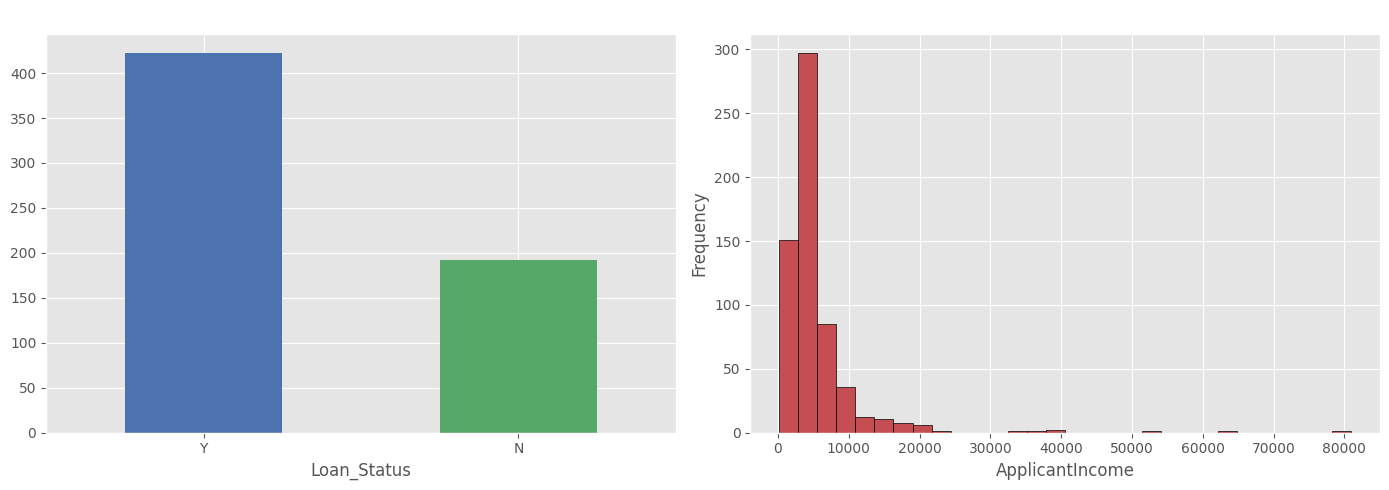

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datos_entrenamiento[TARGET_COLUMN].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"])
axes[0].set_title("Distribución de Loan_Status")
axes[0].set_xlabel("Loan_Status")
axes[0].tick_params(axis="x", rotation=0)

datos_entrenamiento["ApplicantIncome"].dropna().plot(kind="hist", bins=30, ax=axes[1], color="#C44E52", edgecolor="black")
axes[1].set_title("Distribución de ApplicantIncome")
axes[1].set_xlabel("ApplicantIncome")

plt.tight_layout()
plt.show()


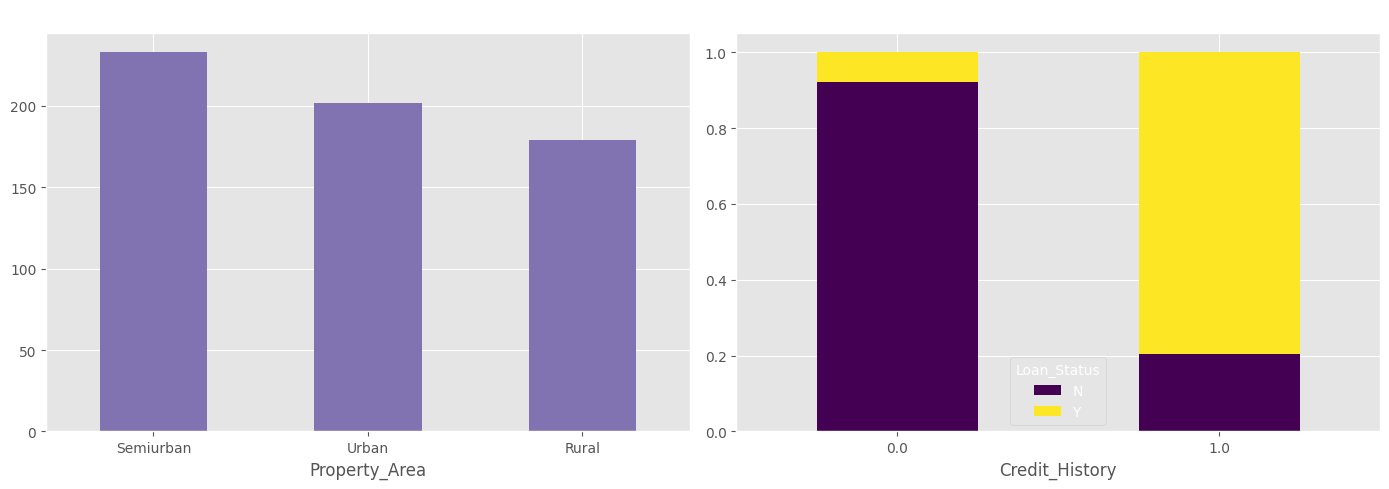

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datos_entrenamiento["Property_Area"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], color="#8172B2")
axes[0].set_title("Conteo por Property_Area")
axes[0].tick_params(axis="x", rotation=0)

aprobacion_por_historial = pd.crosstab(datos_entrenamiento["Credit_History"], datos_entrenamiento[TARGET_COLUMN], normalize="index")
aprobacion_por_historial.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Loan_Status según Credit_History")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Loan_Status")

plt.tight_layout()
plt.show()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000


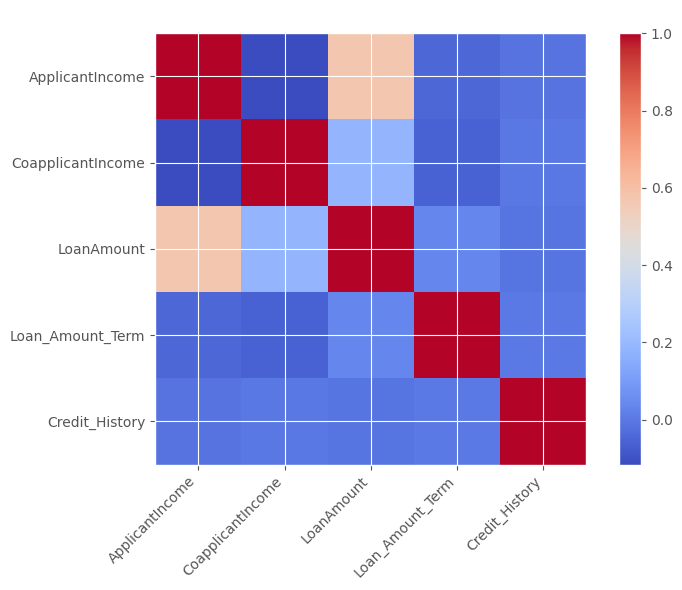

In [55]:
matriz_correlacion = datos_entrenamiento[columnas_numericas].corr(numeric_only=True)
display(matriz_correlacion)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matriz_correlacion, cmap="coolwarm")
ax.set_xticks(range(len(matriz_correlacion.columns)))
ax.set_xticklabels(matriz_correlacion.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matriz_correlacion.index)))
ax.set_yticklabels(matriz_correlacion.index)
ax.set_title("Matriz de correlación")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Parte 3 - Preparación de datos

Limpieza estándar aplicada:
- eliminar identificadores
- manejar faltantes
- codificar variables categóricas
- separar `X` e `y`
- dividir entrenamiento y prueba


In [56]:
datos_modelo_entrenamiento = datos_entrenamiento.copy()
datos_modelo_prueba = datos_prueba.copy()

X = datos_modelo_entrenamiento.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
y = datos_modelo_entrenamiento[TARGET_COLUMN].copy()
X_prueba_final = datos_modelo_prueba.drop(columns=[ID_COLUMN]).copy()

variables_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
variables_categoricas = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            variables_numericas,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            variables_categoricas,
        ),
    ],
    remainder="drop",
)

X_entrenamiento, X_validacion, y_entrenamiento, y_validacion = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

print("X_train:", X_entrenamiento.shape)
print("X_valid:", X_validacion.shape)
print("X_test_final:", X_prueba_final.shape)
print("Features numéricas:", variables_numericas)
print("Features categóricas:", variables_categoricas)


X_train: (491, 11)
X_valid: (123, 11)
X_test_final: (367, 11)
Features numéricas: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Features categóricas: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


## Parte 4 - Modelado

Se entrenan 2 modelos de clasificación:
- Logistic Regression
- Random Forest Classifier


In [57]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "random_forest_classifier": RandomForestClassifier(n_estimators=300, random_state=SEED),
}

modelos_entrenados = {}
resultados = []
predicciones_validacion = {}

for model_name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    pipeline.fit(X_entrenamiento, y_entrenamiento)
    y_pred = pipeline.predict(X_validacion)

    modelos_entrenados[model_name] = pipeline
    predicciones_validacion[model_name] = y_pred
    resultados.append({
        "model": model_name,
        "accuracy": accuracy_score(y_validacion, y_pred),
        "precision": precision_score(y_validacion, y_pred, pos_label="Y"),
        "recall": recall_score(y_validacion, y_pred, pos_label="Y"),
        "f1_score": f1_score(y_validacion, y_pred, pos_label="Y"),
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="f1_score", ascending=False)
display(df_resultados)


,model,accuracy,precision,recall,f1_score
0,logistic_regression,0.861789,0.84000,0.988235,0.908108
1,random_forest_classifier,0.821138,0.83871,0.917647,0.876404


## Parte 5 - Evaluación del modelo

Métricas para clasificación:
- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión


In [58]:
mejor_modelo_nombre = df_resultados.iloc[0]["model"]
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]
mejor_prediccion = predicciones_validacion[mejor_modelo_nombre]

print("Mejor modelo:", mejor_modelo_nombre)
print()
print(classification_report(y_validacion, mejor_prediccion))


Mejor modelo: logistic_regression

              precision    recall  f1-score   support

           N       0.96      0.58      0.72        38
           Y       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



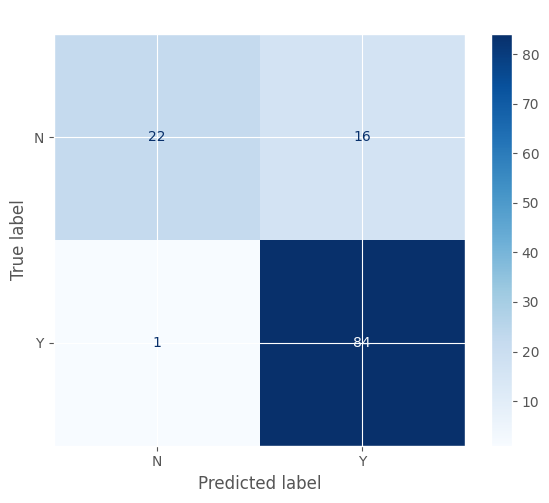

In [59]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(mejor_modelo, X_validacion, y_validacion, ax=ax, cmap="Blues")
ax.set_title(f"Matriz de confusión - {mejor_modelo_nombre}")
plt.tight_layout()
plt.show()


## Parte 6 - Interpretación

**¿Qué tan bueno es el modelo?**  
El modelo muestra un buen desempeño general. El mejor modelo fue `logistic_regression`, con `accuracy = 0.8618`, `precision = 0.84`, `recall = 0.9882` y `f1-score = 0.9081`. Esto indica que predice muy bien la clase `Y`, aunque tiene más dificultad para reconocer la clase `N`.

**¿Qué variable parece influir más en la predicción?**  
La variable que más parece influir es `Credit_History`, ya que obtuvo el valor más alto en la tabla de importancia mostrada en la siguiente celda. Aun así, esta lectura debe tomarse como una referencia aproximada, porque en regresión logística se interpreta a partir de la magnitud de los coeficientes.

**¿Qué mejorarías con más tiempo?**  
Más que agregar complejidad al flujo, lo siguiente sería profundizar el análisis de importancia de variables. El código de la celda siguiente reconstruye los nombres de las variables después del preprocesamiento, extrae el peso de cada una en el modelo y muestra las 10 más influyentes en una tabla y una gráfica.


Nota: en regresión logística, estos valores son magnitudes de coeficientes y solo sirven como referencia aproximada.


,feature,importance
4,Credit_History,3.121592
10,Dependents_1,0.507504
7,Married_No,0.488754
17,Property_Area_Rural,0.454175
14,Education_Not Graduate,0.416563
6,Gender_Male,0.321919
16,Self_Employed_Yes,0.321405
18,Property_Area_Semiurban,0.308348
19,Property_Area_Urban,0.306157
11,Dependents_2,0.210665


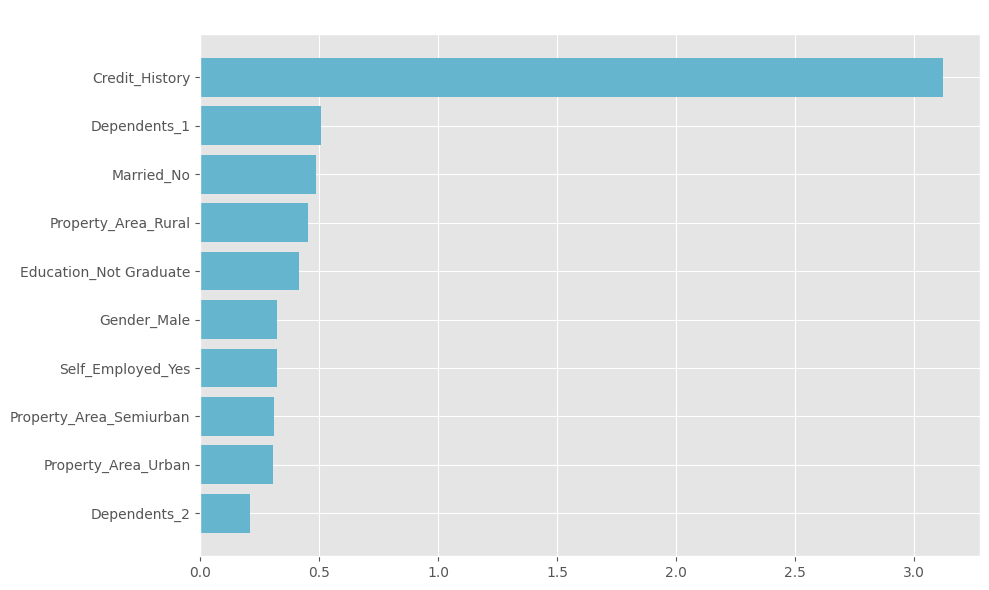

In [60]:
def get_feature_names(preprocessor: ColumnTransformer) -> list[str]:
    nombres_variables = []
    for name, transformer, columns in preprocessor.transformers_:
        if name == "remainder":
            continue
        if hasattr(transformer, "named_steps") and "onehot" in transformer.named_steps:
            onehot = transformer.named_steps["onehot"]
            nombres_variables.extend(onehot.get_feature_names_out(columns).tolist())
        else:
            nombres_variables.extend(list(columns))
    return nombres_variables

paso_modelo = mejor_modelo.named_steps["model"]
nombres_variables_procesadas = get_feature_names(mejor_modelo.named_steps["preprocessor"])

if hasattr(paso_modelo, "feature_importances_"):
    valores_importancia = paso_modelo.feature_importances_
elif hasattr(paso_modelo, "coef_"):
    coef = paso_modelo.coef_
    valores_importancia = np.abs(coef[0]) if np.ndim(coef) > 1 else np.abs(coef)
else:
    valores_importancia = None

if valores_importancia is not None:
    df_importancia = pd.DataFrame({
        "feature": nombres_variables_procesadas,
        "importance": valores_importancia,
    }).sort_values("importance", ascending=False)

    if hasattr(paso_modelo, "coef_"):
        print("Nota: en regresión logística, estos valores son magnitudes de coeficientes y solo sirven como referencia aproximada.")

    display(df_importancia.head(10))

    fig, ax = plt.subplots(figsize=(10, 6))
    variables_top = df_importancia.head(10).sort_values("importance")
    ax.barh(variables_top["feature"], variables_top["importance"], color="#64B5CD")
    ax.set_title(f"Top 10 variables más influyentes - {mejor_modelo_nombre}")
    plt.tight_layout()
    plt.show()


In [61]:
recall_clase_y = recall_score(y_validacion, mejor_prediccion, pos_label="Y")
recall_clase_n = recall_score(y_validacion, mejor_prediccion, pos_label="N")

lectura_modelo = (
    "El modelo tiene buen desempeño general y detecta muy bien la clase Y, "
    "pero identifica con más dificultad la clase N."
    if recall_clase_n < 0.7 else
    "El modelo tiene un desempeño razonablemente balanceado entre ambas clases."
)

interpretacion = {
    "target": TARGET_COLUMN,
    "tipo_problema": "clasificación",
    "mejor_modelo": mejor_modelo_nombre,
    "accuracy": float(df_resultados.iloc[0]["accuracy"]),
    "precision": float(df_resultados.iloc[0]["precision"]),
    "recall": float(df_resultados.iloc[0]["recall"]),
    "f1_score": float(df_resultados.iloc[0]["f1_score"]),
    "que_tan_bueno_es_el_modelo": lectura_modelo,
    "variable_mas_influyente": df_importancia.iloc[0]["feature"] if 'df_importancia' in globals() else "No disponible",
    "que_mejoraria": [
        "Mejorar la detección de la clase N.",
        "Validación cruzada.",
        "Ajuste de hiperparámetros sin complicar demasiado el flujo.",
    ],
}

interpretacion


{'target': 'Loan_Status',
 'tipo_problema': 'clasificación',
 'mejor_modelo': 'logistic_regression',
 'accuracy': 0.8617886178861789,
 'precision': 0.84,
 'recall': 0.9882352941176471,
 'f1_score': 0.9081081081081082,
 'que_tan_bueno_es_el_modelo': 'El modelo tiene buen desempeño general y detecta muy bien la clase Y, pero identifica con más dificultad la clase N.',
 'variable_mas_influyente': 'Credit_History',
 'que_mejoraria': ['Mejorar la detección de la clase N.',
  'Validación cruzada.',
  'Ajuste de hiperparámetros sin complicar demasiado el flujo.']}

## Predicción final sobre el archivo test

Esta sección usa el mejor modelo para generar predicciones sobre `test_Y3wMUE5_7gLdaTN.csv`.

Punto crítico: aquí no hay comparación real de métricas porque el archivo `test` no trae `Loan_Status`. Lo único válido es producir predicciones y revisar su distribución.


In [62]:
predicciones_prueba_final = mejor_modelo.predict(X_prueba_final)

df_predicciones_prueba = datos_prueba[[ID_COLUMN]].copy()
df_predicciones_prueba["Loan_Status_Predicho"] = predicciones_prueba_final

display(df_predicciones_prueba.head(10))
print(df_predicciones_prueba["Loan_Status_Predicho"].value_counts())


,Loan_ID,Loan_Status_Predicho
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y
5,LP001054,Y
6,LP001055,Y
7,LP001056,N
8,LP001059,Y
9,LP001067,Y


Loan_Status_Predicho
Y    306
N     61
Name: count, dtype: int64


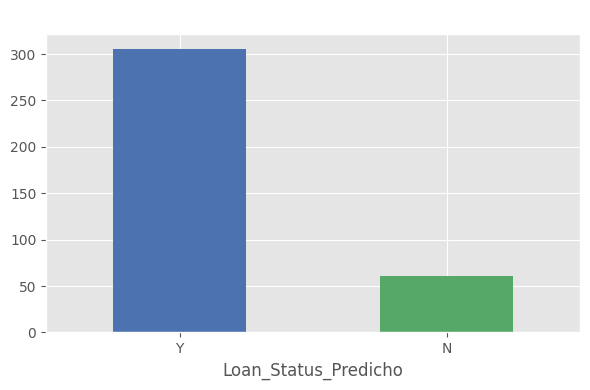

In [63]:
fig, ax = plt.subplots(figsize=(6, 4))
df_predicciones_prueba["Loan_Status_Predicho"].value_counts().plot(kind="bar", color=["#4C72B0", "#55A868"], ax=ax)
ax.set_title("Distribución de predicciones en test")
ax.set_xlabel("Loan_Status_Predicho")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


In [64]:
resumen_comparacion = {
    "mejor_modelo_en_validacion": mejor_modelo_nombre,
    "f1_validacion": float(df_resultados.iloc[0]["f1_score"]),
    "accuracy_validacion": float(df_resultados.iloc[0]["accuracy"]),
    "predicciones_test": df_predicciones_prueba["Loan_Status_Predicho"].value_counts().to_dict(),
    "nota_metodologica": "La comparativa real del desempeño se hace en validación del train, no sobre el test sin etiquetas.",
}

resumen_comparacion


{'mejor_modelo_en_validacion': 'logistic_regression',
 'f1_validacion': 0.9081081081081082,
 'accuracy_validacion': 0.8617886178861789,
 'predicciones_test': {'Y': 306, 'N': 61},
 'nota_metodologica': 'La comparativa real del desempeño se hace en validación del train, no sobre el test sin etiquetas.'}